In [39]:
import matplotlib.pyplot as plt
from pydrake.all import (LeafSystem, BasicVector, DiagramBuilder,
                         Simulator,LinearSystem, ConstantVectorSource, LogVectorOutput,LuenbergerObserver, MatrixGain, 
                         DiscreteTimeDelay) 

import numpy as np
import scipy.linalg as la
import scipy.signal as signal

In [40]:
class TestSYS(LeafSystem):
    def __init__(self):
        LeafSystem.__init__(self)
        num_DTState = 1
        num_input   = 1
        num_output  = 2

        self.DeclareDiscreteState(num_DTState)
        self.DeclareVectorInputPort("u", BasicVector(num_input))
        self.DeclareVectorOutputPort("y", BasicVector(num_output), self.CalcOutput)
        self.DeclarePeriodicDiscreteUpdateEvent(
            period_sec=0.01,  # One second time step.
            offset_sec=0.0,  # The first event is at time zero.
            update=self.DoCalcDiscreteVariableUpdates) # Call the Update method defined below.

    def DoCalcDiscreteVariableUpdates(self, context, discrete_state):
        x = context.get_discrete_state_vector().GetAtIndex(0)
        u = self.get_input_port(0).Eval(context)
        basic_U = BasicVector(1)
        basic_U.SetFromVector(u)
        xnext = 0.98 * x + 5 * basic_U.GetAtIndex(0)
        discrete_state.get_mutable_vector().SetAtIndex(0, xnext)

    def CalcOutput(self, context, output):
        x = context.get_discrete_state_vector().CopyToVector()
        u = self.get_input_port(0).Eval(context)
        y = np.array([x , u])
        output.SetFromVector(y)

Text(0, 0.5, 'y(t)')

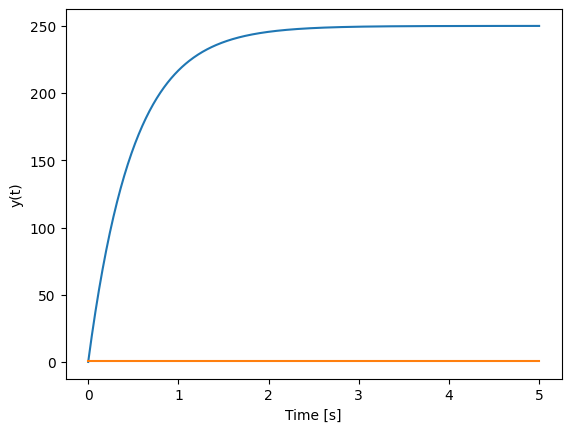

In [41]:
# Build the diagram

builder = DiagramBuilder()
mySys = builder.AddSystem(TestSYS())
const_input = builder.AddSystem(ConstantVectorSource([1.0]))
builder.Connect(const_input.get_output_port(0), mySys.get_input_port(0))
logger = LogVectorOutput(mySys.get_output_port(0), builder)

diagram = builder.Build()

# set the initial condition
context = diagram.CreateDefaultContext()
context.SetDiscreteState([0.0])


# simulate the system
simulator = Simulator(diagram, context)
simulator.AdvanceTo(5)

# plot the results
log = logger.FindLog(context)
plt.figure()
plt.plot(log.sample_times(), log.data().transpose())
plt.xlabel('Time [s]')
plt.ylabel('y(t)')


In [42]:
class CTLinearSysTest(LeafSystem):
    def __init__(self, A, B, C):
        LeafSystem.__init__(self)

        num_state = A.shape[0]
        num_input = B.shape[1]
        num_output = C.shape[0]

        # Define the state vector
        self.DeclareContinuousState(num_state)

        # Define the input
        self.DeclareVectorInputPort("u", BasicVector(num_input))
        
        # Define the output
        self.DeclareVectorOutputPort("y", BasicVector(num_output), self.Output)

        self._A = A
        self._B = B
        self._C = C
    
    def DoCalcTimeDerivatives(self, context, derivatives):
        x = context.get_continuous_state_vector().CopyToVector()
        u = self.get_input_port(0).Eval(context)
        xdot = self._A @ x + self._B @ u
        derivatives.get_mutable_vector().SetFromVector(xdot)
    def Output(self, context, output):
        x = context.get_continuous_state_vector().CopyToVector()
        y = self._C @ x
        output.SetFromVector(y)

Text(0, 0.5, 'y(t)')

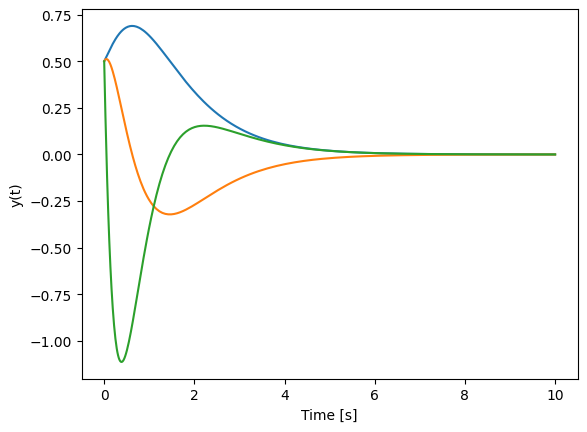

In [43]:
# testing
A = np.array([[0, 1, 0], [0, 0, 1], [-6, -11, -6]])
B = np.array([1, 1, 1]).reshape(3, 1)
C = np.identity(3)
D = np.zeros((3,1))

# Create block
builder = DiagramBuilder()
mySys = builder.AddSystem(CTLinearSysTest(A, B, C))
const_input = builder.AddSystem(ConstantVectorSource([0.0]))
builder.Connect(const_input.get_output_port(0), mySys.get_input_port(0))
logger = LogVectorOutput(mySys.get_output_port(0), builder)
diagram = builder.Build()

# Set the initial condition
context = diagram.CreateDefaultContext()
context.SetContinuousState([0.5, 0.5, 0.5])

# Simulate the system
simulator = Simulator(diagram, context)
simulator.AdvanceTo(10)

# Plot the results
log = logger.FindLog(context)
plt.figure()
plt.plot(log.sample_times(), log.data().transpose())
plt.xlabel('Time [s]')
plt.ylabel('y(t)')


## Simulate open-loop response of the given plant

Text(0, 0.5, 'y(t)')

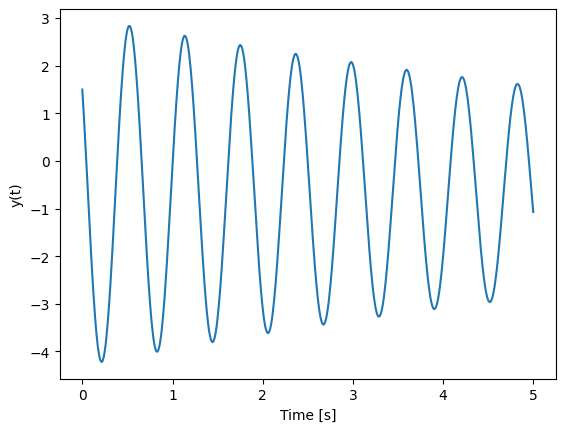

In [44]:
# System with given A, B, C, D matrices
A = np.array([[33, -60], [20, -33.2]])
B = np.array([[1], [1]])
C = np.array([[2, 1]])
D = np.array([[0]])

# Create simple block diagram
builder = DiagramBuilder()
mySys = builder.AddSystem(LinearSystem(A, B, C, D))
step_input = builder.AddSystem(ConstantVectorSource([1.0]))
builder.Connect(step_input.get_output_port(0), mySys.get_input_port(0))
logger = LogVectorOutput(mySys.get_output_port(0), builder)
diagram = builder.Build()

# Set the initial condition
context = diagram.CreateDefaultContext()
context.SetContinuousState([0.5, 0.5])

# Simulate the system
simulator = Simulator(diagram, context)
simulator.AdvanceTo(5)

# Plot the results
log = logger.FindLog(context)
plt.figure()
plt.plot(log.sample_times(), log.data().transpose())
plt.xlabel('Time [s]')
plt.ylabel('y(t)')

## Now let's design of controller + observer

In [50]:
# convert it to discrete time system with Ts = 0.01s
from bdb import Bdb


T = 0.01
Ad = np.eye(A.shape[0]) + A*T
Bd = B*T
Cd = C
D = np.zeros((Cd.shape[0], Bd.shape[1]))


s_desired = np.array([-2 + 1j, -2 - 1j])
z_desired = np.exp(s_desired * T)

# Compute the state feedback gain matrix K
k = signal.place_poles(Ad, Bd, z_desired).gain_matrix

obs_eig_s = np.array([-8 + 1j, -8 - 1j])
obs_eig_z = np.exp(obs_eig_s * T)
# Compute the observer gain matrix L
L = signal.place_poles(Ad.T, Cd.T, obs_eig_z).gain_matrix.T



In [51]:
print(obs_eig_z)
print(la.eig(Ad - L @ Cd))

[0.92307019+0.00923101j 0.92307019-0.00923101j]
(array([0.92307019+0.00923101j, 0.92307019-0.00923101j]), array([[0.91461719+0.j        , 0.91461719-0.j        ],
       [0.40411732-0.01282949j, 0.40411732+0.01282949j]]))


In [52]:
print(k)

[[3.65855144 0.1115158 ]]


Text(0, 0.5, 'y(t)')

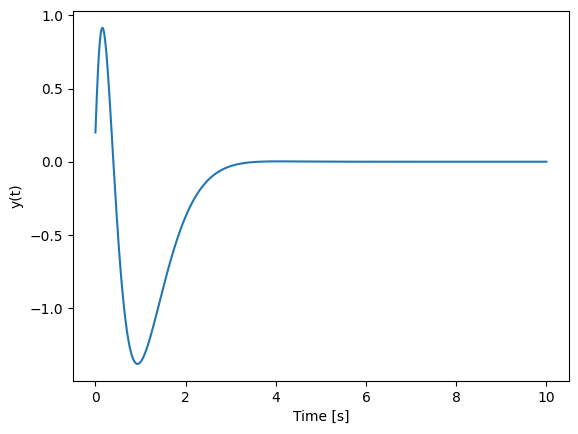

In [57]:
builder = DiagramBuilder()
plant = builder.AddSystem(LinearSystem(Ad, Bd, Cd, D, T))
observer = builder.AddSystem(LuenbergerObserver(plant,plant.CreateDefaultContext(),L))
K_gain = builder.AddSystem(MatrixGain(-k))

builder.Connect(K_gain.get_output_port(0), plant.get_input_port(0))
builder.Connect(K_gain.get_output_port(0), observer.get_input_port(1))
builder.Connect(plant.get_output_port(0), observer.get_input_port(0))
builder.Connect(observer.get_output_port(0), K_gain.get_input_port(0))

logger = LogVectorOutput(plant.get_output_port(0), builder)
diagram = builder.Build()

simulator = Simulator(diagram)
context = simulator.get_mutable_context()

plant_context = diagram.GetMutableSubsystemContext(plant, context)
plant_context.SetDiscreteState([0.1, 0.0])

observer_context = diagram.GetMutableSubsystemContext(observer, context)
observer_context.SetDiscreteState([0.0, 0.0])


simulator.AdvanceTo(10)



# Then plot
log = logger.FindLog(context)
plt.figure()
plt.plot(log.sample_times(), log.data().transpose())
plt.xlabel('Time [s]')
plt.ylabel('y(t)')